# Food delivery operations and customer analytics — EDA

Dataset: [deepeshkansotia/food-delivery-operations-and-customer-analytics](https://www.kaggle.com/datasets/deepeshkansotia/food-delivery-operations-and-customer-analytics).

**Goal:** Characterize orders (timing, geography, customer traits), inspect operational signals (traffic, weather, ratings, fees), and relate them to **actual delivery duration**.

**CSV resolution:** Under `/kaggle/input`, local `data/`, or a `kagglehub` download directory, pick the `.csv` whose header contains **all** `EXPECTED_COLS`; if several match, pick the **largest file by byte size**.


In [1]:
from __future__ import annotations

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

DATASET_SLUG = "deepeshkansotia/food-delivery-operations-and-customer-analytics"
EXPECTED_COLS = [
    "order_id",
    "city_tier",
    "customer_age",
    "customer_loyalty_score",
    "order_hour",
    "order_day_of_week",
    "order_month",
    "delivery_distance_km",
    "preparation_time_minutes",
    "delivery_time_minutes",
    "estimated_delivery_time",
    "traffic_level_score",
    "weather_severity_score",
    "restaurant_rating",
    "delivery_partner_rating",
    "customer_rating",
    "order_value",
    "delivery_fee",
    "discount_amount",
    "tip_amount",
    "final_amount_paid",
    "number_of_items",
    "cancellation_flag",
    "delayed_delivery_flag",
    "refund_flag",
    "promo_code_used",
    "premium_customer_flag",
    "festival_or_weekend_flag",
    "delivery_partner_experience_years",
    "delivery_efficiency_score",
]


def _headers_match(path: Path) -> bool:
    peek = pd.read_csv(path, nrows=0)
    return set(EXPECTED_COLS) <= set(peek.columns)


def resolve_csv_path() -> Path:
    roots: list[Path] = []
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        roots.extend(sorted(kaggle_root.iterdir()))
    local_data = Path("data")
    if local_data.exists():
        roots.append(local_data)
    for root in roots:
        candidates = [p for p in root.rglob("*.csv") if p.is_file() and _headers_match(p)]
        if candidates:
            return max(candidates, key=lambda p: p.stat().st_size)
    hub = Path(kagglehub.dataset_download(DATASET_SLUG))
    candidates = [p for p in hub.rglob("*.csv") if p.is_file() and _headers_match(p)]
    assert candidates, f"no CSV under {hub} with columns {EXPECTED_COLS}"
    return max(candidates, key=lambda p: p.stat().st_size)


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
extra = [c for c in df.columns if c not in EXPECTED_COLS]
assert not extra, f"unexpected columns: {extra}"
df = df[EXPECTED_COLS]

assert len(df) == 15_000
assert df["order_id"].nunique() == 15_000

print(len(df), "rows ×", df.shape[1], "cols")
miss = df.isna().sum()
if miss.any():
    print("Missing values (columns > 0):")
    print(miss[miss > 0])

display(df.sample(5, random_state=7))
display(df.dtypes)
display(df.describe(include=[np.number]).T)

CSV: /kaggle/input/datasets/deepeshkansotia/food-delivery-operations-and-customer-analytics/food_delivery_analytics_cleaned.csv
15000 rows × 30 cols
Missing values (columns > 0):
delivery_partner_rating    150
customer_rating            150
tip_amount                 150
dtype: int64


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
404,fb9fd29d-16a6-44b4-98c3-2b670cb0bff5,3,55,48.500997,17,1,6,10.713119,21,80,...,90.070206,6,False,False,False,False,False,False,7,47.5
5221,be982f94-a1c3-4873-967f-ae929868b067,3,24,33.796980,0,6,4,38.263638,14,119,...,86.271060,8,False,False,False,False,False,True,2,38.0
3357,95441800-6167-434d-87c4-e2c775e3003d,3,69,3.333872,19,1,12,7.438170,56,73,...,100.668123,7,False,False,False,True,False,False,12,81.2
7336,8d01ae7c-8c11-4aa9-a4e4-7f00e242494d,3,46,74.415502,4,1,2,37.768255,39,142,...,162.793371,7,True,False,False,True,False,False,9,41.3
8313,97ba727e-38a0-46fb-9b6e-2dd3aa623009,3,54,72.343383,19,1,9,11.207172,31,83,...,101.699116,12,False,True,True,False,False,False,6,59.0


order_id                              object
city_tier                              int64
customer_age                           int64
customer_loyalty_score               float64
order_hour                             int64
order_day_of_week                      int64
order_month                            int64
delivery_distance_km                 float64
preparation_time_minutes               int64
delivery_time_minutes                  int64
estimated_delivery_time                int64
traffic_level_score                  float64
weather_severity_score               float64
restaurant_rating                    float64
delivery_partner_rating              float64
customer_rating                      float64
order_value                          float64
delivery_fee                         float64
discount_amount                      float64
tip_amount                           float64
final_amount_paid                    float64
number_of_items                        int64
cancellati

,count,mean,std,min,25%,50%,75%,max
city_tier,15000.0,2.253133,0.827951,1.000000,2.000000,3.000000,3.000000,3.000000
customer_age,15000.0,46.569667,16.840706,18.000000,32.000000,46.000000,61.000000,75.000000
customer_loyalty_score,15000.0,50.017658,28.771665,0.007172,25.199828,50.092268,74.840432,99.989375
order_hour,15000.0,11.470933,6.946134,0.000000,5.000000,11.000000,18.000000,23.000000
order_day_of_week,15000.0,3.141933,1.809864,1.000000,1.000000,3.000000,5.000000,6.000000
order_month,15000.0,6.474667,3.454469,1.000000,3.000000,7.000000,9.000000,12.000000
delivery_distance_km,15000.0,20.133756,11.543488,0.103086,10.133190,20.228709,30.047891,39.998739
preparation_time_minutes,15000.0,32.749667,16.162719,5.000000,19.000000,33.000000,47.000000,60.000000
delivery_time_minutes,15000.0,94.139267,33.597132,10.000000,68.000000,95.000000,120.000000,180.000000
estimated_delivery_time,15000.0,94.140667,32.490455,11.000000,69.000000,94.000000,119.000000,178.000000


## Univariate analysis

**Discrete (`city_tier`, `order_day_of_week`, `order_month`):** facet **count plots** (`catplot`), one facet per field.

**Continuous:** distributions with KDE via **`displot`** over a melted long table — facets share axes settings sensibly (`sharex`/`sharey` off across different variables).

**Boolean flags:** facet **counts** (`catplot`) across all flag columns.

Facet layouts make sparse vs dense tails easy to scan when comparing SLA-relevant timings (prep, promised vs actual).


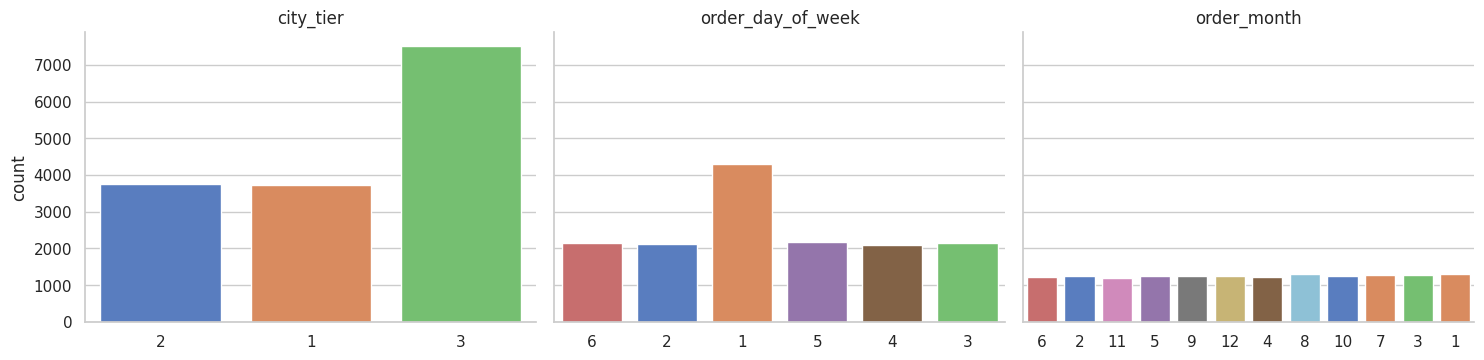

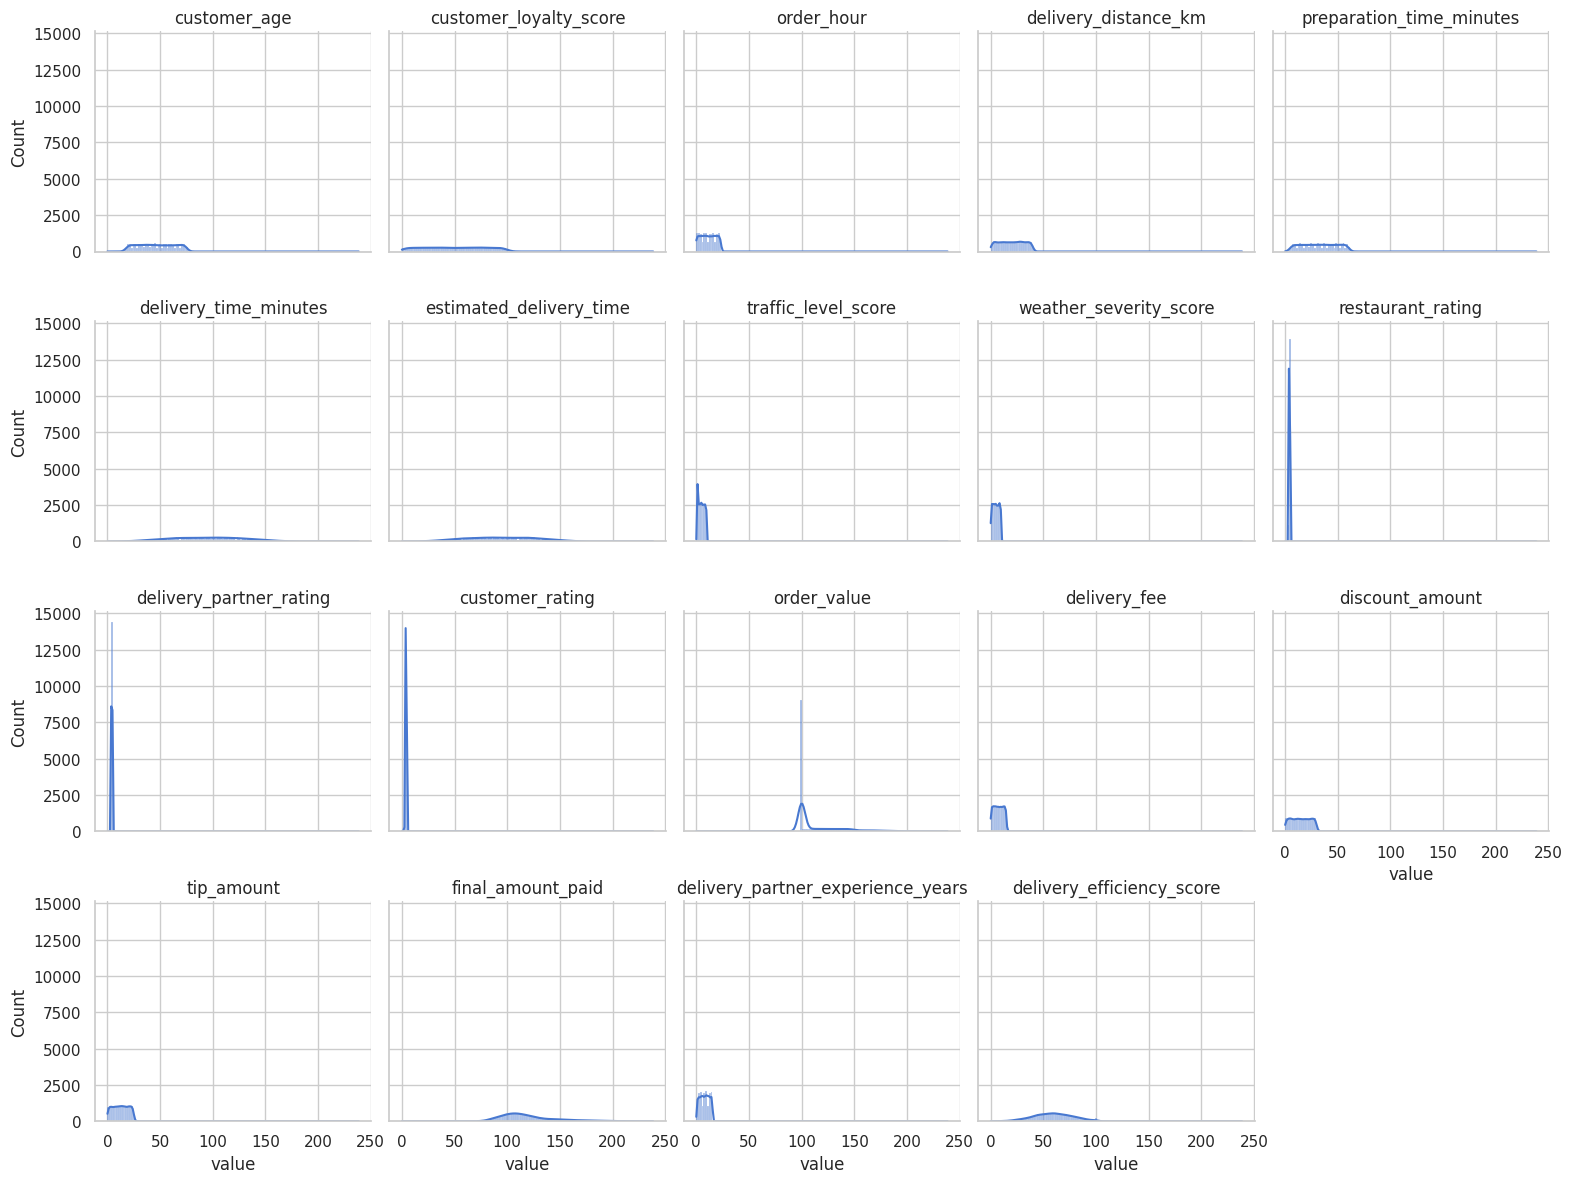

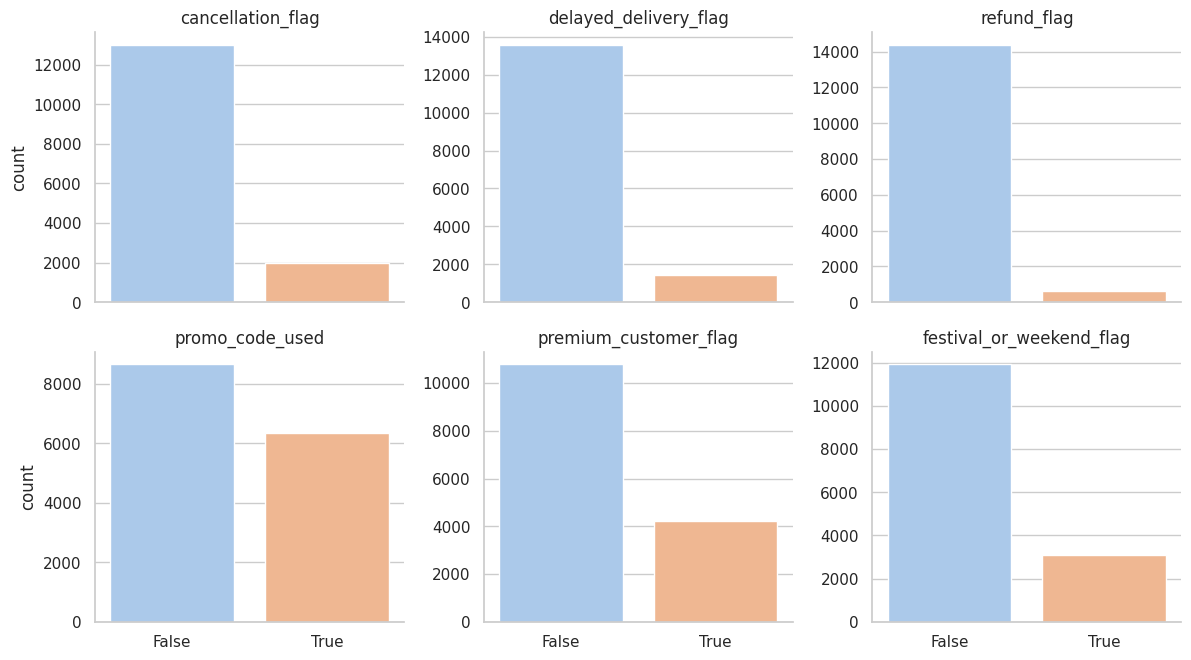

In [2]:
DISCRETE = ["city_tier", "order_day_of_week", "order_month"]

discrete_long = df[DISCRETE].astype(str).melt(var_name="field", value_name="level")
g = sns.catplot(
    data=discrete_long,
    x="level",
    kind="count",
    col="field",
    hue="level",
    palette="muted",
    dodge=False,
    legend=False,
    sharex=False,
    sharey=True,
    height=4,
    aspect=1.25,
)
g.set_axis_labels("", "count")
g.set_titles("{col_name}")
plt.show()

CONTINUOUS_MAIN = [
    "customer_age",
    "customer_loyalty_score",
    "order_hour",
    "delivery_distance_km",
    "preparation_time_minutes",
    "delivery_time_minutes",
]
CONTINUOUS_EXTRA = [
    "estimated_delivery_time",
    "traffic_level_score",
    "weather_severity_score",
    "restaurant_rating",
    "delivery_partner_rating",
    "customer_rating",
    "order_value",
    "delivery_fee",
    "discount_amount",
    "tip_amount",
    "final_amount_paid",
    "delivery_partner_experience_years",
    "delivery_efficiency_score",
]

numeric_blocks = CONTINUOUS_MAIN + CONTINUOUS_EXTRA
long_num = df[numeric_blocks].melt(var_name="variable", value_name="value").dropna(subset=["value"])
g = sns.displot(
    long_num,
    x="value",
    col="variable",
    col_wrap=5,
    kde=True,
    height=3,
    aspect=1.05,
)
g.set_titles("{col_name}")
plt.show()

bool_cols = list(df.select_dtypes(include=bool).columns)
bool_long = df[bool_cols].astype(bool).melt(var_name="flag", value_name="value")
g = sns.catplot(
    data=bool_long,
    x="value",
    kind="count",
    col="flag",
    col_wrap=3,
    hue="value",
    dodge=False,
    legend=False,
    palette="pastel",
    sharey=False,
    height=3.5,
    aspect=1.15,
)
g.set_axis_labels("", "count")
g.set_titles("{col_name}")
plt.show()


### Interpretation (univariate)

- Tier, weekday, and month facets should look **balanced** if the simulator spread orders evenly across those dimensions — otherwise you may want to stratify SLA reporting by whichever dimension concentrates volume.
- **Delivery duration** tails are what hurt customer experience even when means look acceptable; comparing **prep** vs **estimated vs actual delivery** facets highlights where buffer is lost.
- Rows with missing partner/customer rating or tip show up rarely; downstream plots **drop incomplete rows** rather than imputing them.


## Multivariate analysis

Following the standard recipe:

- **Two numeric:** correlation matrix **heatmap** plus **`sns.lmplot`** for linear trend (stratified with **`col`** or **`hue`**).
- **Categorical × numeric:** **`boxplot`** (here: delivery time vs tier — and vs weekday).
- **Two categorical:** **crosstab** with row-normalized percentages and **`heatmap`** (delay vs tier; promo vs delay).

Supporting views: hexbin density for distance × duration (many points), and mean delivery time grid over **hour × tier**.


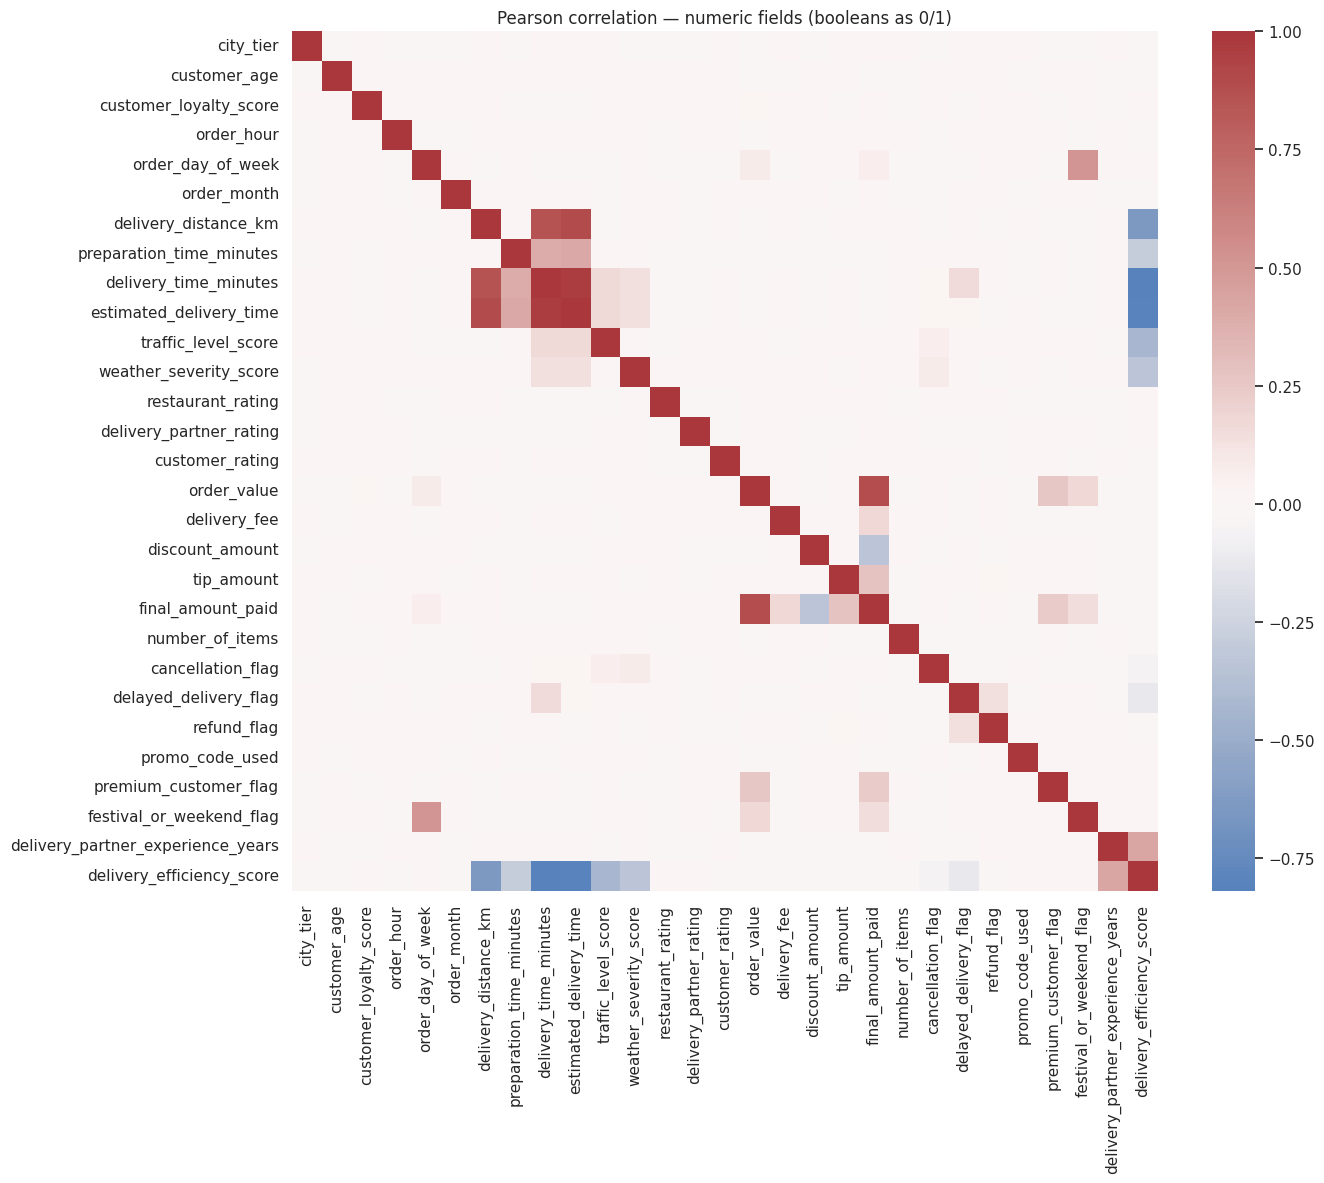

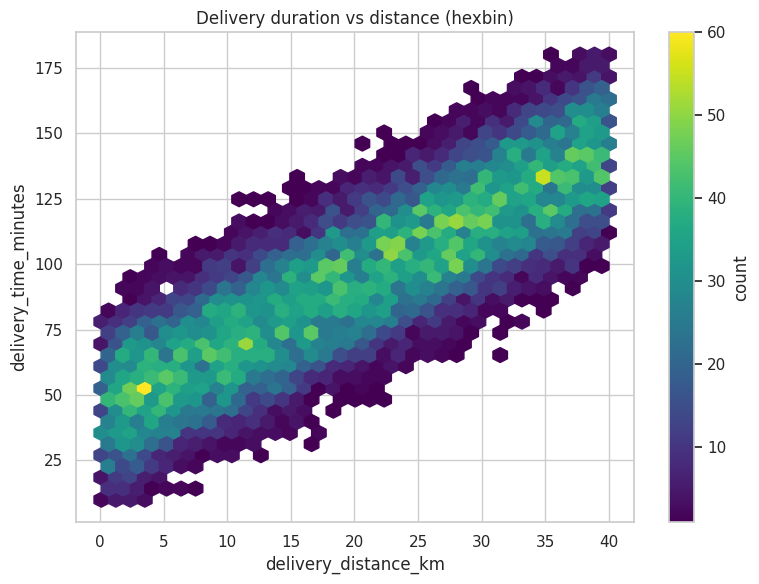

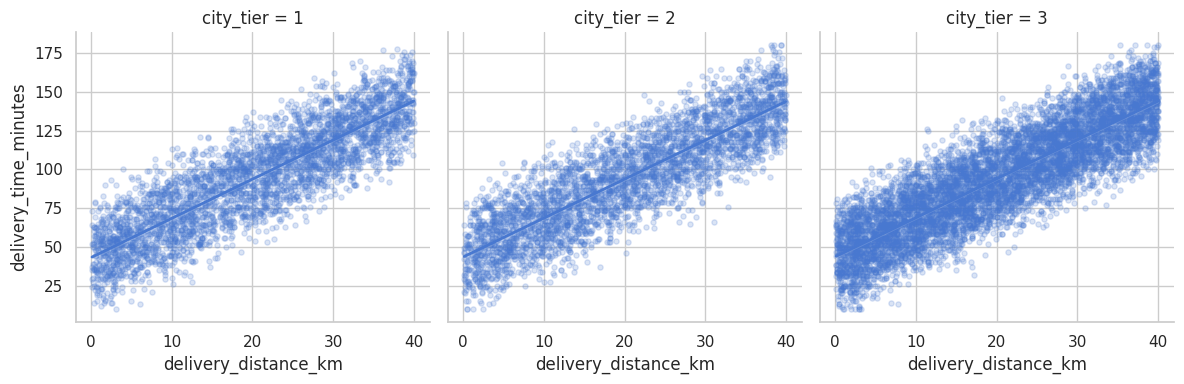

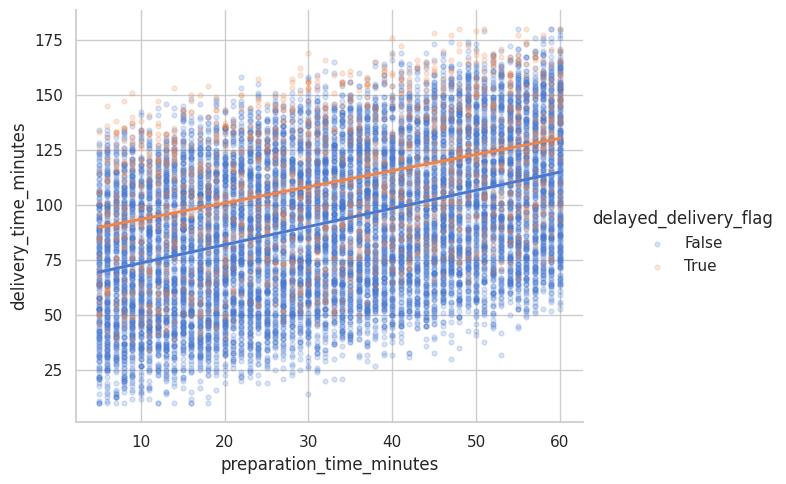

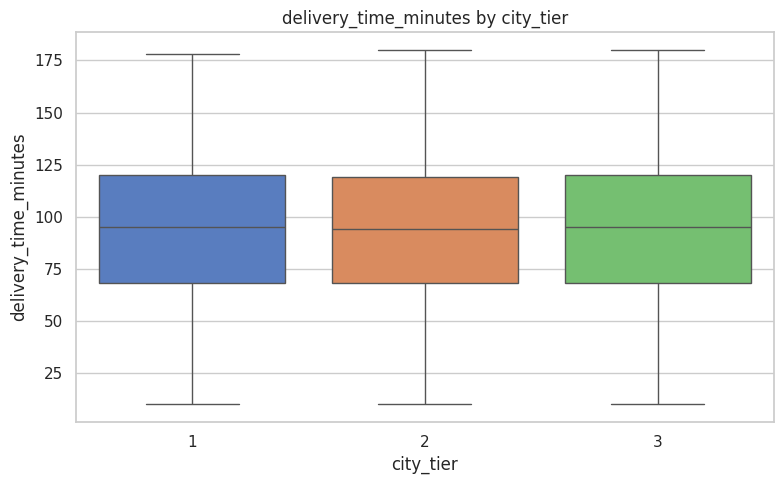

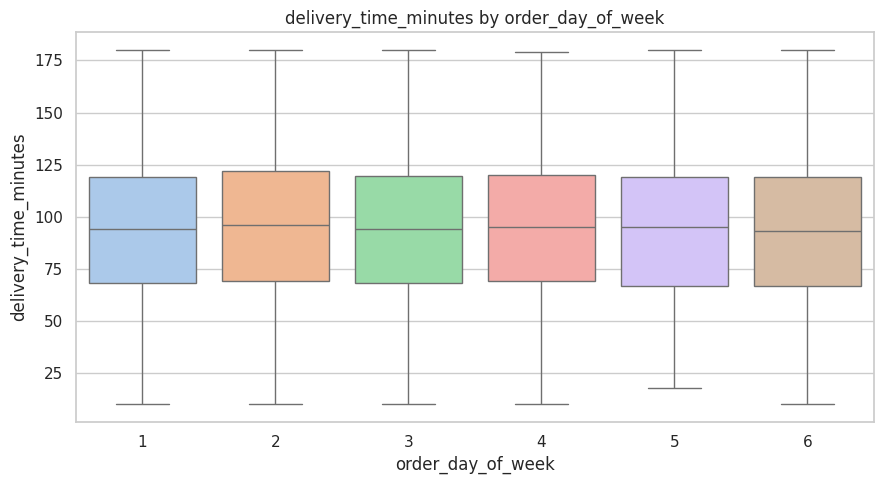

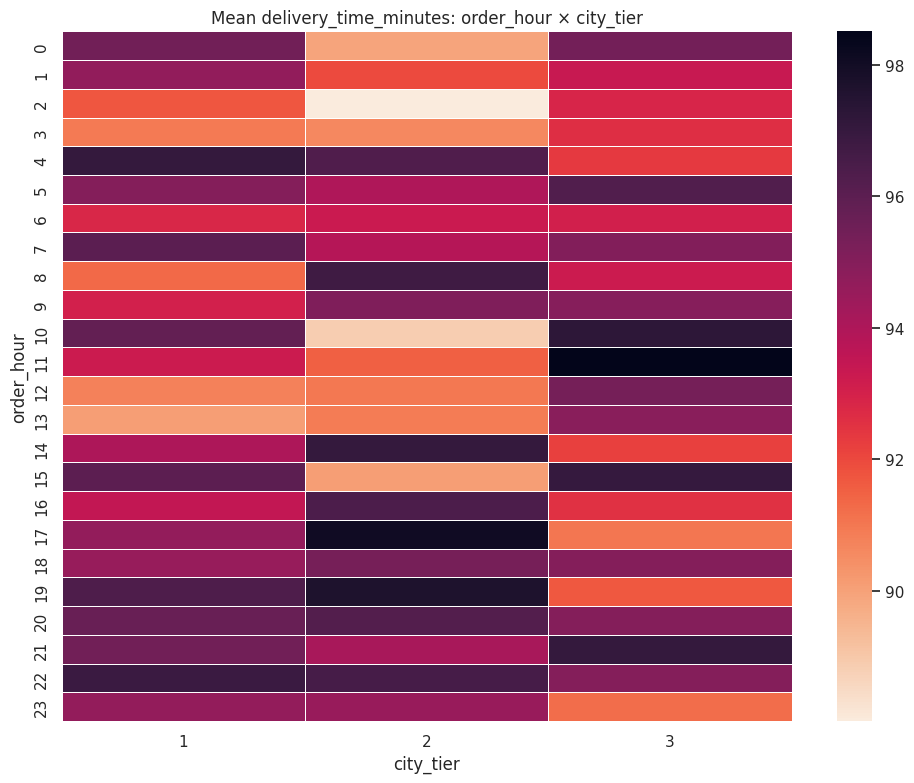

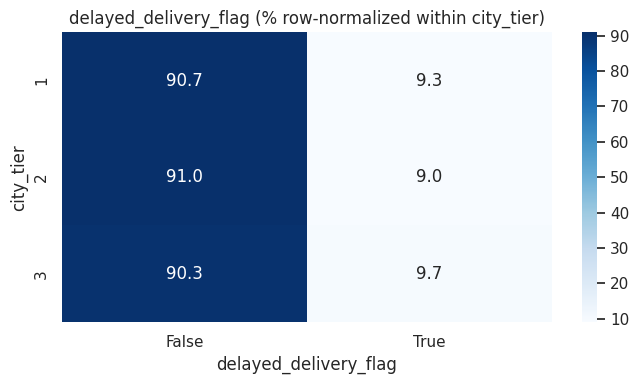

promo_code_used × delayed_delivery_flag (row %)


delayed_delivery_flag,False,True
promo_code_used,,
False,90.43,9.57
True,90.67,9.33


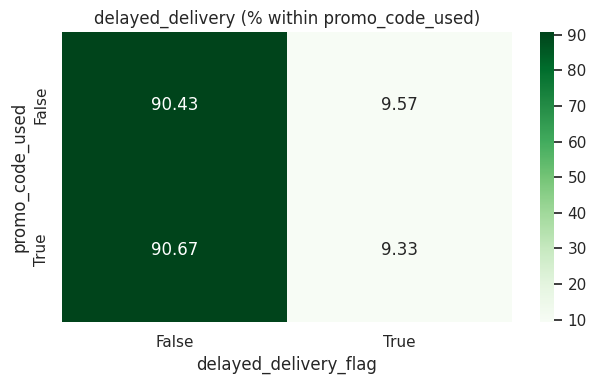

Top absolute Pearson correlation with delivery_time_minutes:
estimated_delivery_time      0.970722
delivery_distance_km         0.863925
delivery_efficiency_score    0.819238
preparation_time_minutes     0.394064
traffic_level_score          0.163487
delayed_delivery_flag        0.157359
weather_severity_score       0.136230
cancellation_flag            0.019753
order_hour                   0.015096
refund_flag                  0.014846
festival_or_weekend_flag     0.014528
order_day_of_week            0.010455


In [3]:
num_df = df.drop(columns=["order_id"]).copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="vlag", center=0, square=False)
plt.title("Pearson correlation — numeric fields (booleans as 0/1)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
hb = plt.hexbin(
    df["delivery_distance_km"],
    df["delivery_time_minutes"],
    gridsize=35,
    cmap="viridis",
    mincnt=1,
)
plt.colorbar(hb, label="count")
plt.xlabel("delivery_distance_km")
plt.ylabel("delivery_time_minutes")
plt.title("Delivery duration vs distance (hexbin)")
plt.tight_layout()
plt.show()

sns.lmplot(
    data=df,
    x="delivery_distance_km",
    y="delivery_time_minutes",
    col="city_tier",
    scatter_kws={"alpha": 0.2, "s": 14},
    line_kws={"linewidth": 2},
    height=4,
    aspect=1,
)
plt.show()

prep_df = df.dropna(subset=["preparation_time_minutes", "delivery_time_minutes"])
sns.lmplot(
    data=prep_df,
    x="preparation_time_minutes",
    y="delivery_time_minutes",
    hue="delayed_delivery_flag",
    scatter_kws={"alpha": 0.2, "s": 12},
    line_kws={"linewidth": 2},
    height=5,
    aspect=1.25,
)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="city_tier", y="delivery_time_minutes", hue="city_tier", palette="muted", legend=False)
plt.title("delivery_time_minutes by city_tier")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
order_day_ordered = sorted(df["order_day_of_week"].unique())
sns.boxplot(
    data=df,
    x="order_day_of_week",
    y="delivery_time_minutes",
    hue="order_day_of_week",
    order=order_day_ordered,
    hue_order=order_day_ordered,
    palette="pastel",
    legend=False,
)
plt.xlabel("order_day_of_week")
plt.title("delivery_time_minutes by order_day_of_week")
plt.tight_layout()
plt.show()

pivot = df.pivot_table(
    values="delivery_time_minutes",
    index="order_hour",
    columns="city_tier",
    aggfunc="mean",
)
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap="rocket_r", linewidths=0.5)
plt.title("Mean delivery_time_minutes: order_hour × city_tier")
plt.tight_layout()
plt.show()

ct_delay_tier = pd.crosstab(df["city_tier"], df["delayed_delivery_flag"], normalize="index") * 100
plt.figure(figsize=(7, 4))
sns.heatmap(ct_delay_tier, annot=True, fmt=".1f", cmap="Blues")
plt.title("delayed_delivery_flag (% row-normalized within city_tier)")
plt.ylabel("city_tier")
plt.xlabel("delayed_delivery_flag")
plt.tight_layout()
plt.show()

ct_promo_delayed = pd.crosstab(df["promo_code_used"], df["delayed_delivery_flag"], normalize="index") * 100
print("promo_code_used × delayed_delivery_flag (row %)")
display(ct_promo_delayed.round(2))
plt.figure(figsize=(6.5, 4))
sns.heatmap(ct_promo_delayed, annot=True, fmt=".2f", cmap="Greens")
plt.title("delayed_delivery (% within promo_code_used)")
plt.ylabel("promo_code_used")
plt.xlabel("delayed_delivery_flag")
plt.tight_layout()
plt.show()

target = "delivery_time_minutes"
assoc = corr[target].drop(labels=[target]).abs().sort_values(ascending=False)
print("Top absolute Pearson correlation with delivery_time_minutes:")
print(assoc.head(12).to_string())


## Summary

- **Breadth:** 15k uniquely keyed orders across logistics, economics, reliability flags, and experience scores — use them together rather than trusting any single KPI.
- **Distance and duration:** The hexbin plus tier-stratified `lmplot` shows whether mileage explains duration similarly in every city tier or only in some segments.
- **Kitchen vs door:** Preparation vs realized delivery slopes that split by **`delayed_delivery_flag`** highlight backlog vs courier effects.
- **Two-way patterns:** Row-normalized crosstabs (tier × delayed, promo × delayed) quantify where delay risk concentrates before targeting interventions.
- **Temporal heatmap:** Mean duration by hour and tier complements weekday boxplots for staffing and ETA tuning.
